# Машинное обучение, ФКН ВШЭ

# Несбалансированные задачи

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты возьмем бинарную задачу, тем не менее, во многом эти методы можно перенести и на задачи с бóльшим числом классов.

In [5]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

### EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [6]:
"""%%bash
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip""";

In [7]:
df = pd.read_csv('creditcard.csv')

In [8]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Посмотрим, какова доля положительных объектов в выборке.

In [9]:
pos_share = df['Class'].mean()
pos_count = df['Class'].sum()
total_count = len(df)

print(f'Число положительных объектов: {pos_count}')
print(f'Общее число объектов: {total_count}')
print(f'Доля положительных объектов: {pos_share:.6f}')
print(f'Доля положительных объектов: {pos_share * 100:.4f}%')

Число положительных объектов: 492
Общее число объектов: 284807
Доля положительных объектов: 0.001727
Доля положительных объектов: 0.1727%


Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, поэтому создадим по ним признаки "час" (от 0 до 23) и "день" (от 0 до ...), принимая первый объект выборки за начальную точку. Посмотрим, сколько дней покрывают данные.

In [10]:
df['hour'] = (df['Time'] // 3600 % 24).astype(int)
df['day'] = (df['Time'] // (24 * 3600)).astype(int)

print('Уникальные дни:', sorted(df['day'].unique()))
print('Количество дней, покрытых данными:', df['day'].nunique())
print(df[['Time', 'hour', 'day']].head())

Уникальные дни: [np.int64(0), np.int64(1)]
Количество дней, покрытых данными: 2
   Time  hour  day
0   0.0     0    0
1   0.0     0    0
2   1.0     0    0
3   1.0     0    0
4   2.0     0    0


Построим следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? Как можно связать полученные часы с реальными часами в сутках?

In [11]:
hour_stats = (
    df.groupby('hour')
      .agg(
          transactions=('Class', 'size'),
          fraud_rate=('Class', 'mean')
      )
      .reset_index()
)

day_stats = (
    df.groupby('day')
      .agg(
          transactions=('Class', 'size'),
          fraud_rate=('Class', 'mean')
      )
      .reset_index()
)

hour_stats

,hour,transactions,fraud_rate
0,0,7695,0.000780
1,1,4220,0.002370
2,2,3328,0.017127
3,3,3492,0.004868
4,4,2209,0.010412
5,5,2990,0.003679
6,6,4101,0.002195
7,7,7243,0.003175
8,8,10276,0.000876
9,9,15838,0.001010


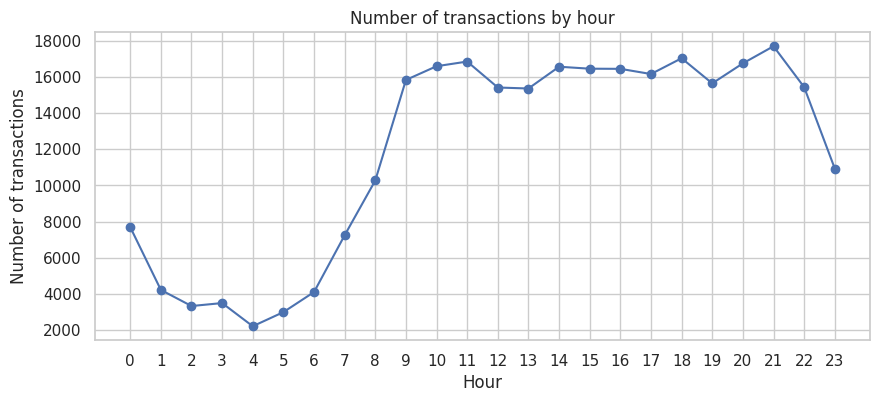

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(hour_stats['hour'], hour_stats['transactions'], marker='o')
plt.xticks(range(24))
plt.xlabel('Hour')
plt.ylabel('Number of transactions')
plt.title('Number of transactions by hour')
plt.show()

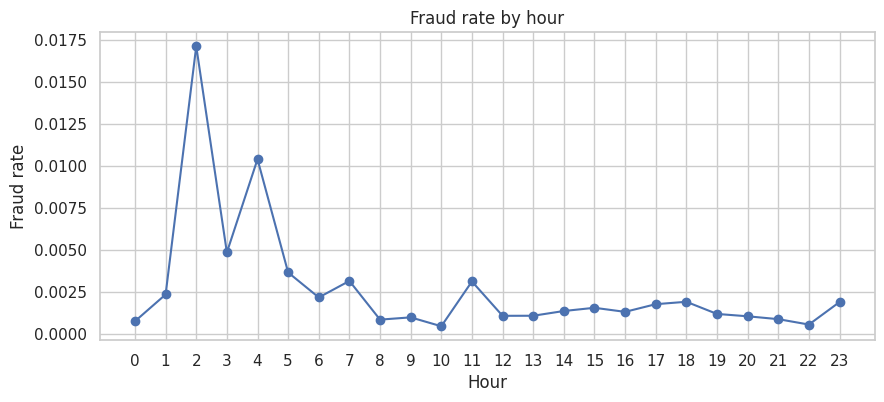

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(hour_stats['hour'], hour_stats['fraud_rate'], marker='o')
plt.xticks(range(24))
plt.xlabel('Hour')
plt.ylabel('Fraud rate')
plt.title('Fraud rate by hour')
plt.show()

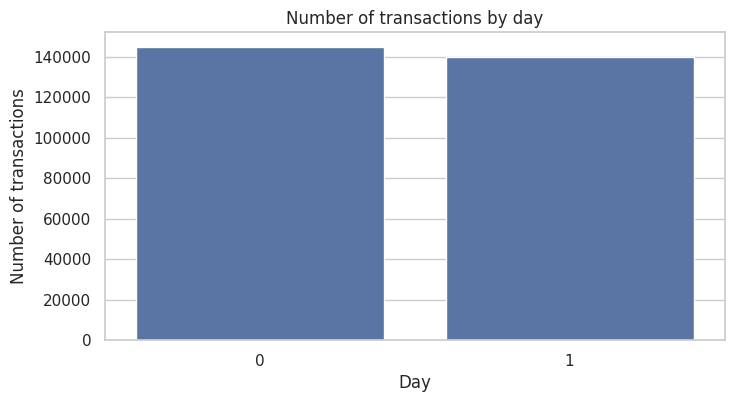

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=day_stats, x='day', y='transactions')
plt.xlabel('Day')
plt.ylabel('Number of transactions')
plt.title('Number of transactions by day')
plt.show()

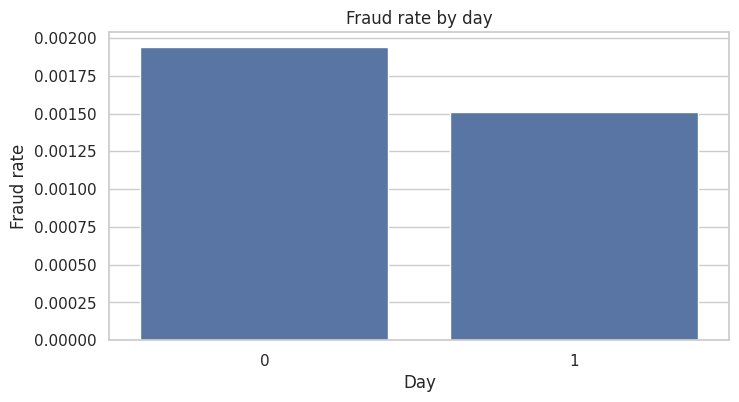

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=day_stats, x='day', y='fraud_rate')
plt.xlabel('Day')
plt.ylabel('Fraud rate')
plt.title('Fraud rate by day')
plt.show()

В выборке наблюдается сильный дисбаланс классов, поэтому accuracy не подойдет в качестве основной метрики, и при обучении модели нужно учитывать дисбаланс классов.

Данные покрывают 2 дня, так как максимальное значение времени немного меньше двух полных суток.

По распределению числа транзакций по часам видно выраженную суточную цикличность:
- в часы 2-5 наблюдается минимум числа транзакций
- начиная примерно с 8-9 часов активность резко растет
- наиболее высокая активность наблюдается в интервале примерно 9-22 часов

Это похоже на обычный дневной ритм пользователей, поэтому можно предположить, что эти часы довольно близки к реальным часам суток, а промежуток с минимальной активностью соответствует ночному времени.

Доля мошеннических транзакций достигает своего пика в ранние часы. Однако в эти часы число транзакций мало, поэтому оценка fraud rate там нестабильна и может сильно меняться из-за небольшого числа мошеннических операций.

По дням видно, что объем транзакций в двух днях сопоставим, но доля мошеннических транзакций в день 0 немного выше.

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуем (например, с помощью корреляции) выбрать несколько наиболее важных признаков и посмотреть на различия в их распределении для разных классов.

In [16]:
corr_with_target = (
    df.drop(columns=['hour', 'day'])
      .corr(numeric_only=True)['Class']
      .drop('Class')
      .sort_values(key=np.abs, ascending=False)
)

top_features = corr_with_target.head(6)
top_features

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961


Теперь разделим данные: отделим хронологически последние 20% транзакций и поделим их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (мошеннические транзакции имеют разное распределение во времени - по-хорошему, стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, больше данных для адекватного контроля не получить, поэтому обойдемся этим.

In [23]:
n = len(df)

train_end = int(n * 0.8)
valid_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

print('train:', train_df.shape)
print('valid:', valid_df.shape)
print('test :', test_df.shape)

train: (227845, 33)
valid: (28481, 33)
test : (28481, 33)


# Несбалансированная классификация

Перед началом работы поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего «ломаются» на задачах с сильным перекосом — например, какое значение accuracy получится для наивного предсказания (мажорный класс для каждого объекта)?

В таких задачах можно использовать `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога.

In [30]:
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']

X_valid = valid_df.drop(columns=['Class'])
y_valid = valid_df['Class']

X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [33]:
def cohen_kappa_score_manual(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    assert y_true.shape == y_pred.shape

    p_o = np.mean(y_true == y_pred)

    p_true_pos = np.mean(y_true == 1)
    p_true_neg = np.mean(y_true == 0)

    p_pred_pos = np.mean(y_pred == 1)
    p_pred_neg = np.mean(y_pred == 0)

    p_e = p_true_pos * p_pred_pos + p_true_neg * p_pred_neg

    if np.isclose(1 - p_e, 0):
        return 0.0

    return (p_o - p_e) / (1 - p_e)

Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом.

In [34]:
def matthews_corrcoef_manual(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    assert y_true.shape == y_pred.shape

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

    if denom == 0:
        return 0.0

    return (tp * tn - fp * fn) / denom

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_metrics(y_true, y_pred, y_score):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'kappa': cohen_kappa_score_manual(y_true, y_pred),
        'mcc': matthews_corrcoef_manual(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'auc_pr': average_precision_score(y_true, y_score)
    }

Заметим, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу — вычислим их значения для наивного предсказания (мажорный класс для всех объектов):

In [64]:
from sklearn.metrics import average_precision_score

y_pred_naive = np.zeros_like(y_test)
y_score_naive = np.zeros_like(y_test, dtype=float)

naive_metrics = get_metrics(y_test, y_pred_naive, y_score_naive)
naive_metrics

{'accuracy': 0.9992275552122467,
 'kappa': np.float64(0.0),
 'mcc': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'auc_pr': np.float64(0.000772444787753239)}

Запустим бейзлайн-решение для нашей задачи — возьмем `catboost` и обучим классификатор на наших данных (используем все признаки). Вычислим значения всех метрик на тестовой части, для контроля переобучения используем валидационную (здесь и далее везде, где фигурирует `catboost`).

In [25]:
!pip3 install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [26]:
from catboost import CatBoostClassifier

In [39]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='PRAUC',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.4699468	test: 0.2828351	best: 0.2828351 (0)	total: 438ms	remaining: 7m 17s
100:	learn: 0.9036023	test: 0.8528372	best: 0.8529654 (98)	total: 16.6s	remaining: 2m 27s
200:	learn: 0.9267521	test: 0.8562568	best: 0.8563070 (197)	total: 26.1s	remaining: 1m 43s
300:	learn: 0.9431530	test: 0.8612783	best: 0.8615633 (295)	total: 36.8s	remaining: 1m 25s
400:	learn: 0.9532317	test: 0.8609102	best: 0.8644333 (330)	total: 54.1s	remaining: 1m 20s
500:	learn: 0.9625590	test: 0.8640550	best: 0.8644333 (330)	total: 1m 5s	remaining: 1m 5s
600:	learn: 0.9706487	test: 0.8667989	best: 0.8677206 (587)	total: 1m 16s	remaining: 50.5s
700:	learn: 0.9792595	test: 0.8698376	best: 0.8701456 (696)	total: 1m 26s	remaining: 37s
800:	learn: 0.9853450	test: 0.8644805	best: 0.8701456 (696)	total: 1m 37s	remaining: 24.2s
900:	learn: 0.9911705	test: 0.8627340	best: 0.8701456 (696)	total: 1m 47s	remaining: 11.8s
999:	learn: 0.9944775	test: 0.8643041	best: 0.8701456 (696)	total: 1m 57s	remaining: 0us

bestTest

CatBoostClassifier(depth=6, eval_metric='PRAUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [65]:
y_valid_score = model.predict_proba(X_valid)[:, 1]
y_test_score = model.predict_proba(X_test)[:, 1]

y_valid_pred = (y_valid_score >= 0.5).astype(int)
y_test_pred = (y_test_score >= 0.5).astype(int)

valid_metrics = get_metrics(y_valid, y_valid_pred, y_valid_score)
test_metrics = get_metrics(y_test, y_test_pred, y_test_score)

print('Validation metrics:')
for k, v in valid_metrics.items():
    print(f'{k}: {v:.6f}')

print('\nTest metrics:')
for k, v in test_metrics.items():
    print(f'{k}: {v:.6f}')

Validation metrics:
accuracy: 0.999473
kappa: 0.834908
mcc: 0.846524
precision: 1.000000
recall: 0.716981
auc_pr: 0.870422

Test metrics:
accuracy: 0.999684
kappa: 0.769075
mcc: 0.775483
precision: 0.882353
recall: 0.681818
auc_pr: 0.706023


Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - добавить вес в функции потерь для минорного класса (так ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это реализовано двумя способами — возьмем отдельный скейлинг для минорного класса. Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Обучим модель с таким скалированием и сравним метрики на тестовой части с бейзлайном.

сохранил бейзлайн

In [43]:
baseline_valid_metrics = valid_metrics.copy()
baseline_test_metrics = test_metrics.copy()

In [44]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

pos_weight = neg_count / pos_count
pos_weight

np.float64(545.3908872901678)

In [51]:
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np

def make_catboost(scale_pos_weight=None):
    params = {
        'iterations': 1000,
        'learning_rate': 0.05,
        'depth': 6,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False
    }

    if scale_pos_weight is not None:
        params['scale_pos_weight'] = scale_pos_weight

    return CatBoostClassifier(**params)

def find_best_threshold(y_true, y_score, metric='mcc'):
    thresholds = np.linspace(0.01, 0.99, 199)

    if metric == 'mcc':
        metric_fn = matthews_corrcoef_manual
    else:
        metric_fn = cohen_kappa_score_manual

    best_threshold = 0.5
    best_value = -np.inf

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        value = metric_fn(y_true, y_pred)

        if value > best_value:
            best_value = value
            best_threshold = threshold

    return best_threshold, best_value

In [66]:
weighted_model = make_catboost(scale_pos_weight=pos_weight)

weighted_model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

weighted_valid_score = weighted_model.predict_proba(X_valid)[:, 1]
weighted_test_score = weighted_model.predict_proba(X_test)[:, 1]

weighted_valid_pred = (weighted_valid_score >= 0.5).astype(int)
weighted_test_pred = (weighted_test_score >= 0.5).astype(int)

weighted_valid_metrics = get_metrics(y_valid, weighted_valid_pred, weighted_valid_score)
weighted_test_metrics = get_metrics(y_test, weighted_test_pred, weighted_test_score)

pd.DataFrame(
    [baseline_test_metrics, weighted_test_metrics],
    index=['baseline', 'weighted_neg_pos']
)

,accuracy,kappa,mcc,precision,recall,auc_pr
baseline,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023
weighted_neg_pos,0.999333,0.627123,0.633126,0.551724,0.727273,0.718156


Поскольку этот вес является гиперпараметром метода, не стоит останавливаться на одном значении. Запустим перебор для этого гиперпараметра на валидационной выборке (используя `PR-AUC`), подберем оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислим все метрики на тестовой части.

При этом также проверим отдельное скалирование в большую сторону для мажорного класса (веса минорного меньше 1) и экстремальные скалирования (веса минорного больше, чем в начале). Посмотрим, какой вес получился оптимальным.

In [68]:
weights_grid = [0.5, 1, 2, 5, 10, pos_weight, 2 * pos_weight]

search_rows = []
fitted_models = []

for weight in weights_grid:
    model = make_catboost(scale_pos_weight=weight)

    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    valid_score = model.predict_proba(X_valid)[:, 1]
    valid_auc_pr = average_precision_score(y_valid, valid_score)

    search_rows.append({
        'weight': weight,
        'valid_auc_pr': valid_auc_pr,
        'best_iteration': model.get_best_iteration()
    })
    fitted_models.append(model)

search_df = pd.DataFrame(search_rows)
search_df.sort_values('valid_auc_pr', ascending=False).reset_index(drop=True)

,weight,valid_auc_pr,best_iteration
0,2.000000,0.865485,340
1,1.000000,0.864704,330
2,5.000000,0.860602,335
3,0.500000,0.857949,389
4,10.000000,0.854364,183
5,545.390887,0.847581,182
6,1090.781775,0.842437,114


In [72]:
best_idx = np.argmax([row['valid_auc_pr'] for row in search_rows])

best_weight = search_rows[best_idx]['weight']
best_model = fitted_models[best_idx]

best_valid_score = best_model.predict_proba(X_valid)[:, 1]
best_threshold, best_valid_metric = find_best_threshold(y_valid, best_valid_score, metric='mcc')

best_test_score = best_model.predict_proba(X_test)[:, 1]
best_test_pred = (best_test_score >= best_threshold).astype(int)

best_weight_test_metrics = get_metrics(y_test, best_test_pred, best_test_score)
best_weight, best_threshold, best_valid_metric, best_weight_test_metrics


(2,
 np.float64(0.16343434343434343),
 np.float64(0.8802894627492476),
 {'accuracy': 0.9994733330992591,
  'kappa': np.float64(0.6805885875737391),
  'mcc': np.float64(0.6819815751994611),
  'precision': 0.64,
  'recall': 0.7272727272727273,
  'auc_pr': np.float64(0.7173197904486271)})

In [73]:
comparison_df = pd.DataFrame(
    [baseline_test_metrics, weighted_test_metrics, best_weight_test_metrics],
    index=['baseline', 'weighted_neg_pos_thr_05', 'weighted_best']
)

comparison_df

,accuracy,kappa,mcc,precision,recall,auc_pr
baseline,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023
weighted_neg_pos_thr_05,0.999333,0.627123,0.633126,0.551724,0.727273,0.718156
weighted_best,0.999473,0.680589,0.681982,0.640000,0.727273,0.717320


взвешивание улучшило PR-AUC и recall, но ухудшило precision и метрики на бинарных предсказаниях по сравнению с baseline. лучший вес - 2.

То, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что можно проделать с целью повысить число объектов минорного класса.

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [74]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE. Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку.

In [77]:
import time
from imblearn.over_sampling import SMOTE

Используем SMOTE для ресэмплинга обучающей выборки, на новой выборке обучим модель (вес положительных объектов скалировать не нужно). Замерим качество на тестовой выборке (**важно!** валидационную и тестовую выборку никак не преобразуем — не хотим отслеживать качество на объектах, которых в реальности не существует). Сравним полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [78]:
smote_strategies = {
    '1:10': 0.1,
    '1:2': 0.5,
    '1:1': 1.0
}

smote_rows = []

for i, (name, ratio) in enumerate(smote_strategies.items(), 1):
    print(f'[{i}/{len(smote_strategies)}] SMOTE {name}')

    start_time = time.time()

    smote = SMOTE(
        sampling_strategy=ratio,
        random_state=42,
        k_neighbors=5
    )

    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    print(f'  resampled size: {len(y_resampled)}')

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='PRAUC',
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        X_resampled, y_resampled,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    valid_score = model.predict_proba(X_valid)[:, 1]
    test_score = model.predict_proba(X_test)[:, 1]

    valid_pred = (valid_score >= 0.5).astype(int)
    test_pred = (test_score >= 0.5).astype(int)

    valid_metrics_smote = get_metrics(y_valid, valid_pred, valid_score)
    test_metrics_smote = get_metrics(y_test, test_pred, test_score)

    elapsed = time.time() - start_time
    print(f'  time: {elapsed:.1f} sec')

    smote_rows.append({
        'strategy': name,
        'train_size_after_smote': len(y_resampled),
        'valid_auc_pr': valid_metrics_smote['auc_pr'],
        'test_accuracy': test_metrics_smote['accuracy'],
        'test_kappa': test_metrics_smote['kappa'],
        'test_mcc': test_metrics_smote['mcc'],
        'test_precision': test_metrics_smote['precision'],
        'test_recall': test_metrics_smote['recall'],
        'test_auc_pr': test_metrics_smote['auc_pr'],
        'time_sec': elapsed
    })

smote_results = pd.DataFrame(smote_rows)
smote_results

[1/3] SMOTE 1:10
  resampled size: 250170
  time: 22.7 sec
[2/3] SMOTE 1:2
  resampled size: 341142
  time: 52.2 sec
[3/3] SMOTE 1:1
  resampled size: 454856
  time: 48.2 sec


,strategy,train_size_after_smote,valid_auc_pr,test_accuracy,test_kappa,test_mcc,test_precision,test_recall,test_auc_pr,time_sec
0,1:10,250170,0.842272,0.998771,0.477069,0.508006,0.355556,0.727273,0.700318,22.727186
1,1:2,341142,0.836874,0.999228,0.592219,0.602662,0.500000,0.727273,0.722203,52.176990
2,1:1,454856,0.826236,0.997999,0.358805,0.416048,0.238806,0.727273,0.723670,48.153462


In [82]:
baseline_row = pd.DataFrame([{
    'strategy': 'baseline',
    'train_size_after_smote': len(y_train),
    'valid_auc_pr': baseline_valid_metrics['auc_pr'],
    'test_accuracy': baseline_test_metrics['accuracy'],
    'test_kappa': baseline_test_metrics['kappa'],
    'test_mcc': baseline_test_metrics['mcc'],
    'test_precision': baseline_test_metrics['precision'],
    'test_recall': baseline_test_metrics['recall'],
    'test_auc_pr': baseline_test_metrics['auc_pr'],
    'time_sec': np.nan
}])

pd.concat([baseline_row, smote_results], ignore_index=True)

,strategy,train_size_after_smote,valid_auc_pr,test_accuracy,test_kappa,test_mcc,test_precision,test_recall,test_auc_pr,time_sec
0,baseline,227845,0.870422,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023,NaN
1,1:10,250170,0.842272,0.998771,0.477069,0.508006,0.355556,0.727273,0.700318,22.727186
2,1:2,341142,0.836874,0.999228,0.592219,0.602662,0.500000,0.727273,0.722203,52.176990
3,1:1,454856,0.826236,0.997999,0.358805,0.416048,0.238806,0.727273,0.723670,48.153462


Для vanilla SMOTE существуют некоторые модификации, часть из которых реализована в библиотеке imblearn — исследуем их тоже.

Найдем статьи о следующих методах и вкратце сформулируем, в чем их основная идея:

BorderlineSMOTE - генерирует новые объекты вблизи границы между классами, около наиболее сложных объектов минорного класса.

SVM-SMOTE - использует SVM, чтобы найти область границы разделения классов, и создает новые объекты рядом с ней. За счет этого oversampling становится более направленным.

K-Means-SMOTE - сначала разбивает данные на кластеры, а затем применяет SMOTE внутри подходящих кластеров, что позволяет учитывать структуру данных и уменьшать генерацию шума.

ADASYN - создает больше синтетических объектов в тех областях, где минорный класс представлен хуже и классификация сложнее.

Теперь сравним качество всех методов на наших данных.

In [84]:
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, ADASYN

samplers = {
    'BorderlineSMOTE': BorderlineSMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5),
    'SVMSMOTE': SVMSMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=5),
    'KMeansSMOTE': KMeansSMOTE(
        sampling_strategy=0.5,
        random_state=42,
        k_neighbors=3,
        cluster_balance_threshold=0.001
    ),
    'ADASYN': ADASYN(sampling_strategy=0.5, random_state=42, n_neighbors=5)
}

bonus_rows = []
times = []

for i, (name, sampler) in enumerate(samplers.items(), 1):
    print(f'[{i}/{len(samplers)}] {name}')
    start_time = time.time()

    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    print(f'  resampled size: {len(y_resampled)}')

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='PRAUC',
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        X_resampled, y_resampled,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    valid_score = model.predict_proba(X_valid)[:, 1]
    test_score = model.predict_proba(X_test)[:, 1]

    valid_pred = (valid_score >= 0.5).astype(int)
    test_pred = (test_score >= 0.5).astype(int)

    valid_metrics_cur = get_metrics(y_valid, valid_pred, valid_score)
    test_metrics_cur = get_metrics(y_test, test_pred, test_score)

    elapsed = time.time() - start_time
    times.append(elapsed)

    left = len(samplers) - i
    est_left = np.mean(times) * left if left > 0 else 0

    print(f'  time: {elapsed:.1f} sec')
    if left > 0:
        print(f'  estimated time left: {est_left:.1f} sec')

    bonus_rows.append({
        'method': name,
        'train_size_after_resampling': len(y_resampled),
        'valid_auc_pr': valid_metrics_cur['auc_pr'],
        'test_accuracy': test_metrics_cur['accuracy'],
        'test_kappa': test_metrics_cur['kappa'],
        'test_mcc': test_metrics_cur['mcc'],
        'test_precision': test_metrics_cur['precision'],
        'test_recall': test_metrics_cur['recall'],
        'test_auc_pr': test_metrics_cur['auc_pr'],
        'time_sec': elapsed
    })

bonus_results = pd.DataFrame(bonus_rows).sort_values('test_auc_pr', ascending=False).reset_index(drop=True)
bonus_results

[1/4] BorderlineSMOTE
  resampled size: 341142
  time: 25.1 sec
  estimated time left: 75.3 sec
[2/4] SVMSMOTE
  resampled size: 341142
  time: 40.8 sec
  estimated time left: 65.9 sec
[3/4] KMeansSMOTE
  resampled size: 341148
  time: 20.9 sec
  estimated time left: 28.9 sec
[4/4] ADASYN
  resampled size: 341015
  time: 31.1 sec


,method,train_size_after_resampling,valid_auc_pr,test_accuracy,test_kappa,test_mcc,test_precision,test_recall,test_auc_pr,time_sec
0,ADASYN,341015,0.834883,0.997472,0.306848,0.375901,0.195122,0.727273,0.719897,31.127151
1,BorderlineSMOTE,341142,0.845499,0.999263,0.603415,0.612324,0.516129,0.727273,0.675890,25.106560
2,SVMSMOTE,341142,0.848170,0.999473,0.680589,0.681982,0.640000,0.727273,0.674458,40.787891
3,KMeansSMOTE,341148,0.839852,0.999508,0.695407,0.696066,0.666667,0.727273,0.559032,20.868171


In [85]:
baseline_bonus_row = pd.DataFrame([{
    'method': 'baseline',
    'train_size_after_resampling': len(y_train),
    'valid_auc_pr': baseline_valid_metrics['auc_pr'],
    'test_accuracy': baseline_test_metrics['accuracy'],
    'test_kappa': baseline_test_metrics['kappa'],
    'test_mcc': baseline_test_metrics['mcc'],
    'test_precision': baseline_test_metrics['precision'],
    'test_recall': baseline_test_metrics['recall'],
    'test_auc_pr': baseline_test_metrics['auc_pr'],
    'time_sec': np.nan
}])

pd.concat([baseline_bonus_row, bonus_results], ignore_index=True)

,method,train_size_after_resampling,valid_auc_pr,test_accuracy,test_kappa,test_mcc,test_precision,test_recall,test_auc_pr,time_sec
0,baseline,227845,0.870422,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023,NaN
1,ADASYN,341015,0.834883,0.997472,0.306848,0.375901,0.195122,0.727273,0.719897,31.127151
2,BorderlineSMOTE,341142,0.845499,0.999263,0.603415,0.612324,0.516129,0.727273,0.675890,25.106560
3,SVMSMOTE,341142,0.848170,0.999473,0.680589,0.681982,0.640000,0.727273,0.674458,40.787891
4,KMeansSMOTE,341148,0.839852,0.999508,0.695407,0.696066,0.666667,0.727273,0.559032,20.868171


До этого момента все наши решения концентрировались на работе с минорным классом. Теперь попробуем зайти с другой стороны — может быть, для восстановления закономерностей не нужно столько объектов мажорного класса, и они просто засоряют выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока не получим приемлемый баланс. Протестируем следующий метод и построим графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [86]:
from imblearn.under_sampling import RandomUnderSampler

In [87]:
rus_strategies = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

rus_rows = []
rus_times = []

for i, ratio in enumerate(rus_strategies, 1):
    print(f'[{i}/{len(rus_strategies)}] ratio = {ratio}')
    start_time = time.time()

    sampler = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='PRAUC',
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        X_resampled, y_resampled,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    test_score = model.predict_proba(X_test)[:, 1]
    test_pred = (test_score >= 0.5).astype(int)
    test_metrics_cur = get_metrics(y_test, test_pred, test_score)

    elapsed = time.time() - start_time
    rus_times.append(elapsed)

    original_size = len(y_train)
    resampled_size = len(y_resampled)

    left = len(rus_strategies) - i
    est_left = np.mean(rus_times) * left if left > 0 else 0

    print(f'  resampled size: {resampled_size}')
    print(f'  time: {elapsed:.1f} sec')
    if left > 0:
        print(f'  estimated time left: {est_left:.1f} sec')

    rus_rows.append({
        'ratio': ratio,
        'resampled_size': resampled_size,
        'compression_ratio': original_size / resampled_size,
        'accuracy': test_metrics_cur['accuracy'],
        'kappa': test_metrics_cur['kappa'],
        'mcc': test_metrics_cur['mcc'],
        'precision': test_metrics_cur['precision'],
        'recall': test_metrics_cur['recall'],
        'auc_pr': test_metrics_cur['auc_pr'],
        'time_sec': elapsed
    })

rus_results = pd.DataFrame(rus_rows)
rus_results

[1/7] ratio = 0.01
  resampled size: 42117
  time: 19.3 sec
  estimated time left: 115.7 sec
[2/7] ratio = 0.02
  resampled size: 21267
  time: 10.9 sec
  estimated time left: 75.5 sec
[3/7] ratio = 0.05
  resampled size: 8757
  time: 2.4 sec
  estimated time left: 43.4 sec
[4/7] ratio = 0.1
  resampled size: 4587
  time: 6.3 sec
  estimated time left: 29.2 sec
[5/7] ratio = 0.2
  resampled size: 2502
  time: 2.7 sec
  estimated time left: 16.6 sec
[6/7] ratio = 0.5
  resampled size: 1251
  time: 1.8 sec
  estimated time left: 7.2 sec
[7/7] ratio = 1.0
  resampled size: 834
  time: 4.7 sec


,ratio,resampled_size,compression_ratio,accuracy,kappa,mcc,precision,recall,auc_pr,time_sec
0,0.01,42117,5.409811,0.999438,0.651893,0.652511,0.625000,0.681818,0.705144,19.276688
1,0.02,21267,10.713547,0.999438,0.651893,0.652511,0.625000,0.681818,0.705402,10.904590
2,0.05,8757,26.018614,0.999087,0.551294,0.568126,0.444444,0.727273,0.687872,2.386210
3,0.10,4587,49.671899,0.998350,0.404399,0.451209,0.280702,0.727273,0.670160,6.339680
4,0.20,2502,91.065148,0.996735,0.255052,0.335181,0.155340,0.727273,0.684716,2.701047
5,0.50,1251,182.130296,0.995962,0.216658,0.304052,0.128000,0.727273,0.682434,1.816165
6,1.00,834,273.195444,0.986798,0.081584,0.182072,0.043814,0.772727,0.708585,4.662261


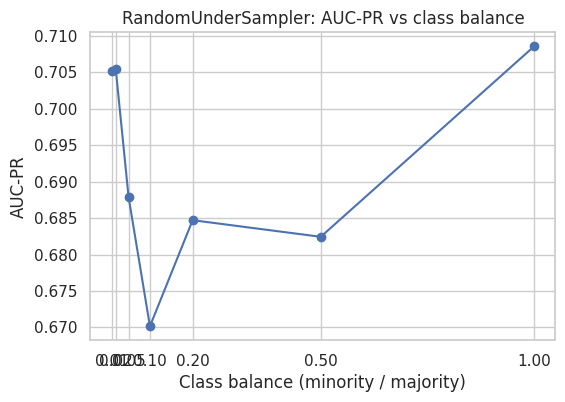

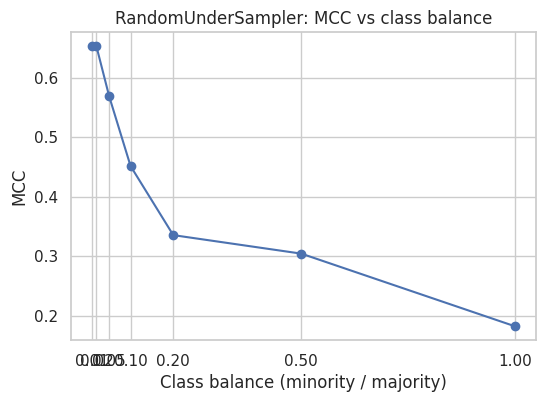

In [96]:
metric_names = {
    'auc_pr': 'AUC-PR',
    'mcc': 'MCC'
}

for metric in ['auc_pr', 'mcc']:
    plt.figure(figsize=(6, 4))
    plt.plot(rus_results['ratio'], rus_results[metric], marker='o')
    plt.xticks(rus_results['ratio'])
    plt.xlabel('Class balance (minority / majority)')
    plt.ylabel(metric_names[metric])
    plt.title(f'RandomUnderSampler: {metric_names[metric]} vs class balance')
    plt.show()

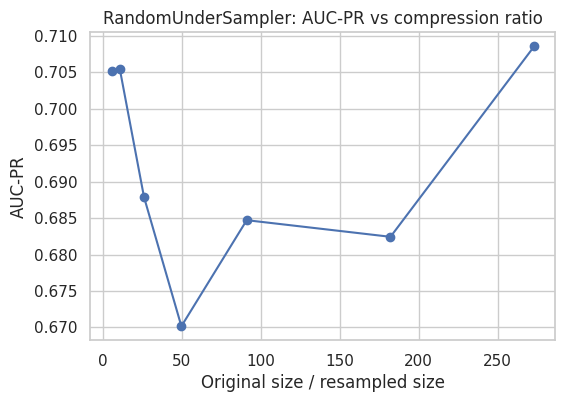

In [97]:
plt.figure(figsize=(6, 4))
plt.plot(rus_results['compression_ratio'], rus_results['auc_pr'], marker='o')
plt.xlabel('Original size / resampled size')
plt.ylabel('AUC-PR')
plt.title('RandomUnderSampler: AUC-PR vs compression ratio')
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять качество - например, при отбрасывании можно использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируем алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и построим графики, аналогичные предыдущему пункту (также добавим график с зависимостью качества от числа соседей).

In [91]:
from imblearn.under_sampling import NearMiss

nm_strategies = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

nm_rows = []
nm_times = []

for i, ratio in enumerate(nm_strategies, 1):
    print(f'[{i}/{len(nm_strategies)}] ratio = {ratio}')
    start_time = time.time()

    sampler = NearMiss(sampling_strategy=ratio, version=1, n_neighbors=3)
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='PRAUC',
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        X_resampled, y_resampled,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    test_score = model.predict_proba(X_test)[:, 1]
    test_pred = (test_score >= 0.5).astype(int)
    test_metrics_cur = get_metrics(y_test, test_pred, test_score)

    elapsed = time.time() - start_time
    nm_times.append(elapsed)

    original_size = len(y_train)
    resampled_size = len(y_resampled)

    left = len(nm_strategies) - i
    est_left = np.mean(nm_times) * left if left > 0 else 0

    print(f'  resampled size: {resampled_size}')
    print(f'  time: {elapsed:.1f} sec')
    if left > 0:
        print(f'  estimated time left: {est_left:.1f} sec')

    nm_rows.append({
        'ratio': ratio,
        'n_neighbors': 3,
        'resampled_size': resampled_size,
        'compression_ratio': original_size / resampled_size,
        'accuracy': test_metrics_cur['accuracy'],
        'kappa': test_metrics_cur['kappa'],
        'mcc': test_metrics_cur['mcc'],
        'precision': test_metrics_cur['precision'],
        'recall': test_metrics_cur['recall'],
        'auc_pr': test_metrics_cur['auc_pr'],
        'time_sec': elapsed
    })

nm_results = pd.DataFrame(nm_rows)
nm_results

[1/7] ratio = 0.01
  resampled size: 42117
  time: 12.3 sec
  estimated time left: 73.6 sec
[2/7] ratio = 0.02
  resampled size: 21267
  time: 4.0 sec
  estimated time left: 40.6 sec
[3/7] ratio = 0.05
  resampled size: 8757
  time: 3.4 sec
  estimated time left: 26.2 sec
[4/7] ratio = 0.1
  resampled size: 4587
  time: 6.5 sec
  estimated time left: 19.6 sec
[5/7] ratio = 0.2
  resampled size: 2502
  time: 4.8 sec
  estimated time left: 12.4 sec
[6/7] ratio = 0.5
  resampled size: 1251
  time: 4.1 sec
  estimated time left: 5.8 sec
[7/7] ratio = 1.0
  resampled size: 834
  time: 2.7 sec


,ratio,n_neighbors,resampled_size,compression_ratio,accuracy,kappa,mcc,precision,recall,auc_pr,time_sec
0,0.01,3,42117,5.409811,0.999614,0.685534,0.709417,0.923077,0.545455,0.677368,12.266912
1,0.02,3,21267,10.713547,0.999473,0.633884,0.635590,0.684211,0.590909,0.668881,3.978497
2,0.05,3,8757,26.018614,0.999052,0.525866,0.540129,0.428571,0.681818,0.652120,3.385042
3,0.10,3,4587,49.671899,0.938801,0.017635,0.082222,0.009687,0.772727,0.571934,6.530352
4,0.20,3,2502,91.065148,0.992240,0.125248,0.222930,0.069264,0.727273,0.691233,4.830619
5,0.50,3,1251,182.130296,0.961940,0.028941,0.106130,0.015511,0.772727,0.686767,4.103657
6,1.00,3,834,273.195444,0.919244,0.013057,0.070403,0.007353,0.772727,0.660283,2.731401


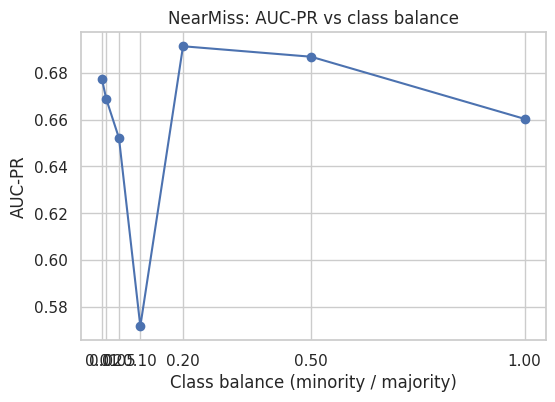

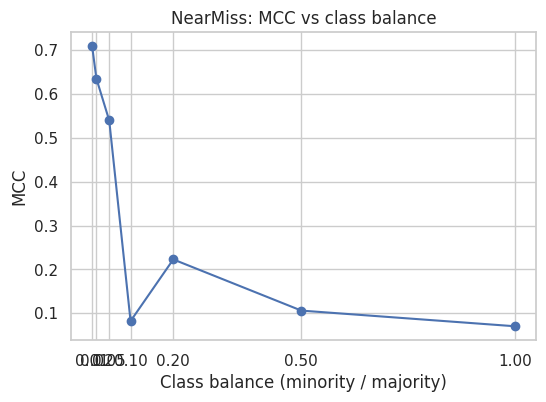

In [98]:
for metric in ['auc_pr', 'mcc']:
    plt.figure(figsize=(6, 4))
    plt.plot(nm_results['ratio'], nm_results[metric], marker='o')
    plt.xticks(nm_results['ratio'])
    plt.xlabel('Class balance (minority / majority)')
    plt.ylabel(metric_names[metric])
    plt.title(f'NearMiss: {metric_names[metric]} vs class balance')
    plt.show()

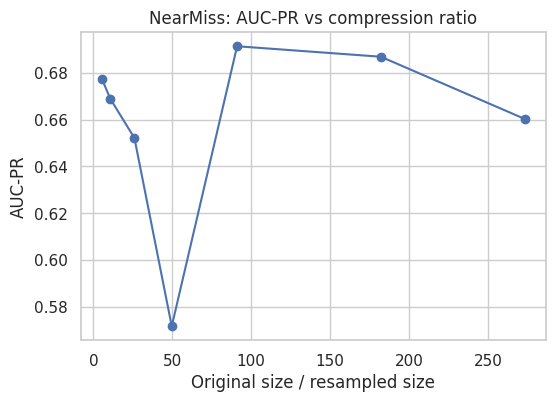

In [99]:
plt.figure(figsize=(6, 4))
plt.plot(nm_results['compression_ratio'], nm_results['auc_pr'], marker='o')
plt.xlabel('Original size / resampled size')
plt.ylabel('AUC-PR')
plt.title('NearMiss: AUC-PR vs compression ratio')
plt.show()

зависимость от числа соседей:

In [94]:
neighbor_grid = [1, 3, 5, 7, 9]
fixed_ratio = 0.1

nm_neighbors_rows = []
nm_neighbors_times = []

for i, n_neighbors in enumerate(neighbor_grid, 1):
    print(f'[{i}/{len(neighbor_grid)}] n_neighbors = {n_neighbors}')
    start_time = time.time()

    sampler = NearMiss(
        sampling_strategy=fixed_ratio,
        version=1,
        n_neighbors=n_neighbors
    )

    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='PRAUC',
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        X_resampled, y_resampled,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    test_score = model.predict_proba(X_test)[:, 1]
    test_pred = (test_score >= 0.5).astype(int)
    test_metrics_cur = get_metrics(y_test, test_pred, test_score)

    elapsed = time.time() - start_time
    nm_neighbors_times.append(elapsed)

    left = len(neighbor_grid) - i
    est_left = np.mean(nm_neighbors_times) * left if left > 0 else 0

    print(f'  time: {elapsed:.1f} sec')
    if left > 0:
        print(f'  estimated time left: {est_left:.1f} sec')

    nm_neighbors_rows.append({
        'n_neighbors': n_neighbors,
        'ratio': fixed_ratio,
        'accuracy': test_metrics_cur['accuracy'],
        'kappa': test_metrics_cur['kappa'],
        'mcc': test_metrics_cur['mcc'],
        'precision': test_metrics_cur['precision'],
        'recall': test_metrics_cur['recall'],
        'auc_pr': test_metrics_cur['auc_pr'],
        'time_sec': elapsed
    })

nm_neighbors_results = pd.DataFrame(nm_neighbors_rows)
nm_neighbors_results

[1/5] n_neighbors = 1
  time: 4.6 sec
  estimated time left: 18.4 sec
[2/5] n_neighbors = 3
  time: 4.7 sec
  estimated time left: 14.0 sec
[3/5] n_neighbors = 5
  time: 3.5 sec
  estimated time left: 8.5 sec
[4/5] n_neighbors = 7
  time: 4.7 sec
  estimated time left: 4.4 sec
[5/5] n_neighbors = 9
  time: 7.3 sec


,n_neighbors,ratio,accuracy,kappa,mcc,precision,recall,auc_pr,time_sec
0,1,0.1,0.994698,0.173740,0.267612,0.099379,0.727273,0.653311,4.594736
1,3,0.1,0.938801,0.017635,0.082222,0.009687,0.772727,0.571934,4.723973
2,5,0.1,0.948000,0.020952,0.089858,0.011386,0.772727,0.632889,3.502464
3,7,0.1,0.695903,0.003290,0.039245,0.002419,0.954545,0.642283,4.657943
4,9,0.1,0.898880,0.011507,0.070096,0.006561,0.863636,0.675231,7.295352


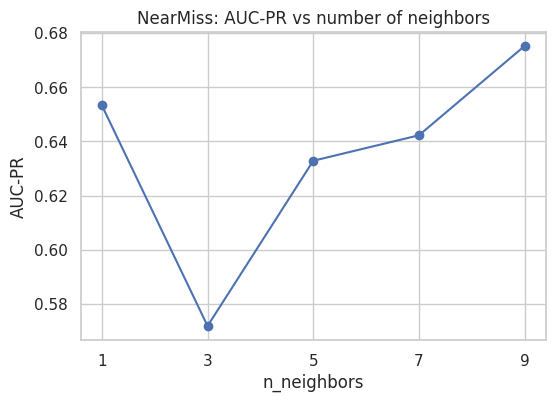

In [100]:
plt.figure(figsize=(6, 4))
plt.plot(nm_neighbors_results['n_neighbors'], nm_neighbors_results['auc_pr'], marker='o')
plt.xticks(nm_neighbors_results['n_neighbors'])
plt.xlabel('n_neighbors')
plt.ylabel('AUC-PR')
plt.title('NearMiss: AUC-PR vs number of neighbors')
plt.show()

imblearn также предлагает много различных методов для андерсэмплинга. Возьмем что-нибудь еще на свой вкус, опишем идею метода и протестируем его.

Я взял TomekLinks - он удаляет объекты мажорного класса, которые образуют с объектами минорного класса слишком близкие пары. Метод должен очистить границу между классами и убрать неоднозначные объекты.

In [101]:
from imblearn.under_sampling import TomekLinks

start_time = time.time()

sampler = TomekLinks()
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='PRAUC',
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

model.fit(
    X_resampled, y_resampled,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

test_score = model.predict_proba(X_test)[:, 1]
test_pred = (test_score >= 0.5).astype(int)

tomek_metrics = get_metrics(y_test, test_pred, test_score)

elapsed = time.time() - start_time

print('Resampled train size:', len(y_resampled))
print('Original train size:', len(y_train))
print('Time:', round(elapsed, 1), 'sec')
tomek_metrics

Resampled train size: 227785
Original train size: 227845
Time: 616.3 sec


{'accuracy': 0.9996488887328394,
 'kappa': np.float64(0.7498260790128308),
 'mcc': np.float64(0.7536088618289372),
 'precision': 0.8333333333333334,
 'recall': 0.6818181818181818,
 'auc_pr': np.float64(0.6924833662232207)}

In [102]:
pd.DataFrame(
    [baseline_test_metrics, tomek_metrics],
    index=['baseline', 'tomek_links']
)

,accuracy,kappa,mcc,precision,recall,auc_pr
baseline,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023
tomek_links,0.999649,0.749826,0.753609,0.833333,0.681818,0.692483


TomekLinks удалил только небольшое число объектов мажорного класса, поэтому обучающая выборка почти не изменилась. На тестовой выборке качество оказалось немного ниже бейзлайна: recall сохранился, но precision, MCC и AUC-PR немного ухудшились.

# Поиск аномалий

Как можно заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка.

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных).

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



На занятиях мы разбирали похожий на Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения строится ансамбль решающих деревьев, в котором признак и порог для каждой вершины подбираются случайно, а затем оценка аномальности объекта считается через длину пути до соответствующего листа в каждом дереве.

Реализуем модификацию этого алгоритма — Extended Isolation Forest. В ней на каждом шаге вместо порога для одного признака определяется случайная гиперплоскость, разбивающая выборку на две части. Подробное описание — в [статье](https://arxiv.org/pdf/1811.02141.pdf).

Будем считать, что в датасете нет категориальных признаков, так что отдельно их обрабатывать не нужно. Дополнительно делаем EIF параллельным (`joblib`) и добавляем возможность откатиться к дефолтному варианту Isolation Forest.

In [110]:
from joblib import Parallel, delayed

def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    if n <= 1:
        return 0.0
    if n == 2:
        return 1.0
    return 2.0 * (np.log(n - 1) + 0.5772156649) - 2.0 * (n - 1) / n

def calc_height(X, depth, node):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node

        depth: int - path length up to current node

        node: Node - current tree node

    Returns:
        scores: int, float or np.array - anomaly scores for sample
    """
    scores = np.zeros(X.shape[0], dtype=float)

    if X.shape[0] == 0:
        return scores

    if node.kind == 'external':
        return np.full(X.shape[0], depth + c_factor(node.size), dtype=float)

    proj = X @ node.w
    left_mask = proj <= node.b
    right_mask = ~left_mask

    if left_mask.any():
        scores[left_mask] = calc_height(X[left_mask], depth + 1, node.left)
    if right_mask.any():
        scores[right_mask] = calc_height(X[right_mask], depth + 1, node.right)

    return scores


class Node(object):
    """
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.

    Attributes:
        X: np.array - data available to current node
        size: int - length of available data

        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either "internal" or "external", indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    """
    def __init__(self, X, depth, left, right, kind, w, b):
        """
        Node(h, left, right, kind, w, b)
        Represents the node object.

        Params:
            X: np.array - data available to current node
            depth: int - depth of node

            left: Node - left child
            right: Node - right child

            kind: str - either "internal" or "external", indicates the type of current node

            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane

        """
        self.size = len(X)

        self.depth = depth

        self.left = left
        self.right = right

        self.kind = kind

        self.w = w
        self.b = b

    def __repr__(self):
        """
        For convenience only.
        """
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"

class RandomizedTree(object):
    """
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth

        max_depth: int - maximum tree depth

        root: Node - root node

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes

    """
    def __init__(self, X, max_depth, random_state=None):
        self.depth = 0
        self.max_depth = max_depth
        self.internal_count = 0
        self.external_count = 0
        self.rng = np.random.default_rng(random_state)
        self.root = self.grow(X, 0)

    def __repr__(self):
        """
        For convenience only.
        """

        return f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})"



    def grow(self, X, depth):
        """
        Grow tree in a recursive manner.
        Params:
            X: np.array - available train sample

            depth: int - current tree depth

        Returns:
            node: Node - a trained node with separating hyperplane data.
                         Node provides access to children if necessary (these are built recursively)
        """
        self.depth = max(self.depth, depth)

        if depth >= self.max_depth or len(X) <= 1:
            self.external_count += 1
            left = None
            right = None
            kind = 'external'
            w = None
            b = None
            return Node(X, depth, left, right, kind, w, b)

        if np.all(np.std(X, axis=0) < 1e-12):
            self.external_count += 1
            left = None
            right = None
            kind = 'external'
            w = None
            b = None
            return Node(X, depth, left, right, kind, w, b)

        n_features = X.shape[1]
        success = False

        for _ in range(20):
            w = self.rng.normal(size=n_features)
            norm = np.linalg.norm(w)

            if norm < 1e-12:
                continue

            w = w / norm
            proj = X @ w
            p_min, p_max = proj.min(), proj.max()

            if np.isclose(p_min, p_max):
                continue

            b = self.rng.uniform(p_min, p_max)
            left_mask = proj <= b

            if 0 < left_mask.sum() < len(X):
                success = True
                break

        if not success:
            self.external_count += 1
            left = None
            right = None
            kind = 'external'
            w = None
            b = None
            return Node(X, depth, left, right, kind, w, b)

        self.internal_count += 1
        left = self.grow(X[left_mask], depth + 1)
        right = self.grow(X[~left_mask], depth + 1)
        kind = 'internal'

        return Node(X, depth, left, right, kind, w, b)

    def score_samples(self, X):
        """
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated

        Returns:
            scores: np.array - estimated anomaly scores
        """
        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)
        scores = calc_height(X, 0, self.root)

        return scores

def _fit_one_tree(X, subsample_size, max_depth, seed):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=subsample_size, replace=False)
    X_sub = X[idx]
    return RandomizedTree(X_sub, max_depth=max_depth, random_state=seed)

class ExtendedIsolationForest(object):
    """
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees

        max_depth: int - maximum depth of each tree

        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

        trees: list - container for trained trees

        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

    """

    def __init__(self, n_trees, subsample_rate, max_depth=None, contamination=0.01, n_jobs=1, random_state=42):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.contamination = contamination
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.is_fit = False
        self.subsample_size_ = None
        self.c_ = None
        self.threshold_ = None
        self.max_depth_ = None

    def __repr__(self):
        """For convenience only."""

        return f"ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})"

    def fit(self, X):
        """
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        """
        X = np.asarray(X, dtype=float)

        if self.subsample_rate <= 1:
            self.subsample_size_ = max(2, int(np.ceil(self.subsample_rate * X.shape[0])))
        else:
            self.subsample_size_ = min(int(self.subsample_rate), X.shape[0])

        if self.max_depth is None:
            self.max_depth_ = int(np.ceil(np.log2(self.subsample_size_)))
        else:
            self.max_depth_ = self.max_depth

        rng = np.random.default_rng(self.random_state)
        seeds = rng.integers(0, 10**9, size=self.n_trees)

        self.trees = Parallel(n_jobs=self.n_jobs, prefer='threads')(
            delayed(_fit_one_tree)(X, self.subsample_size_, self.max_depth_, int(seed))
            for seed in seeds
        )

        self.c_ = c_factor(self.subsample_size_)
        self.is_fit = True

        train_scores = self.score_samples(X)
        self.threshold_ = np.quantile(train_scores, 1 - self.contamination)

        return self

    def score_samples(self, X):
        """
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        """
        if not self.is_fit:
            raise ValueError('Model is not fitted yet.')

        X = np.asarray(X, dtype=float)

        all_heights = Parallel(n_jobs=self.n_jobs, prefer='threads')(
            delayed(tree.score_samples)(X) for tree in self.trees
        )

        mean_heights = np.mean(np.vstack(all_heights), axis=0)
        scores = 2 ** (-mean_heights / self.c_)

        return scores


    def predict(self, X):
        """
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        """
        scores = self.score_samples(X)
        labels = (scores >= self.threshold_).astype(int)
        return labels


In [119]:
from sklearn.preprocessing import StandardScaler

anomaly_features = [col for col in train_df.columns if col.startswith('V')]

X_train_anom = train_df[anomaly_features].copy()
X_valid_anom = valid_df[anomaly_features].copy()
X_test_anom = test_df[anomaly_features].copy()

y_train_anom = train_df['Class'].to_numpy()
y_valid_anom = valid_df['Class'].to_numpy()
y_test_anom = test_df['Class'].to_numpy()

scaler = StandardScaler()

X_train_anom = scaler.fit_transform(X_train_anom)
X_valid_anom = scaler.transform(X_valid_anom)
X_test_anom = scaler.transform(X_test_anom)

In [120]:
subsample_size = 1024
subsample_rate = subsample_size / X_train_anom.shape[0]


eif = ExtendedIsolationForest(
    n_trees=100,
    subsample_rate=subsample_rate,
    max_depth=None,
    contamination=y_train_anom.mean(),
    n_jobs=-1,
    random_state=42
)

eif.fit(X_train_anom)

print(eif)

ExtendedIsolationForest(n_trees=100, max_depth=None, subsample_rate=0.004494283394412869, contamination=0.001830191577607584, is_fit=True)


In [121]:
valid_scores = eif.score_samples(X_valid_anom)
test_scores = eif.score_samples(X_test_anom)


best_threshold, best_valid_mcc = find_best_threshold(y_valid_anom, valid_scores, metric='mcc')
best_threshold, best_valid_mcc

(np.float64(0.5346464646464646), np.float64(0.24762801902157566))

In [122]:
valid_pred_default = eif.predict(X_valid_anom)
test_pred_default = eif.predict(X_test_anom)

valid_metrics_default = get_metrics(y_valid_anom, valid_pred_default, valid_scores)
test_metrics_default = get_metrics(y_test_anom, test_pred_default, test_scores)

valid_pred_tuned = (valid_scores >= best_threshold).astype(int)
test_pred_tuned = (test_scores >= best_threshold).astype(int)

valid_metrics_tuned = get_metrics(y_valid_anom, valid_pred_tuned, valid_scores)
test_metrics_tuned = get_metrics(y_test_anom, test_pred_tuned, test_scores)

pd.DataFrame(
    [valid_metrics_default, valid_metrics_tuned, test_metrics_default, test_metrics_tuned],
    index=['valid_default', 'valid_tuned', 'test_default', 'test_tuned']
)

,accuracy,kappa,mcc,precision,recall,auc_pr
valid_default,0.996770,-0.001580,-0.001599,0.000000,0.000000,0.064927
valid_tuned,0.984867,0.150409,0.247628,0.085526,0.735849,0.064927
test_default,0.998315,-0.000838,-0.000840,0.000000,0.000000,0.025145
test_tuned,0.985640,0.049651,0.113494,0.026895,0.500000,0.025145


In [123]:
pd.DataFrame(
    [baseline_test_metrics, test_metrics_tuned],
    index=['catboost_baseline', 'extended_isolation_forest']
)

,accuracy,kappa,mcc,precision,recall,auc_pr
catboost_baseline,0.999684,0.769075,0.775483,0.882353,0.681818,0.706023
extended_isolation_forest,0.985640,0.049651,0.113494,0.026895,0.500000,0.025145


Для обучения использовал только признаки V1-V28, так как они представляют собой основные анонимизированные характеристики транзакций.

Стандартный порог оказался слишком жестким и практически не находил аномалии, поэтому дополнительно был подобран порог по валидационной выборке по MCC. После этого модель начала обнаруживать часть мошеннических транзакций, однако итоговое качество осталось невысоким: удалось повысить recall, но precision и AUC-PR остались низкими. Это ожидаемо для unsupervised-подхода в задаче обнаружения редких аномалий (ну нас предупредили).

Реализация была распараллелена с помощью joblib: построение деревьев и вычисление оценок по ансамблю выполнялись параллельно, что ускорило обучение.

Протестируем реализацию EIF и подберем оптимальные гиперпараметры (метод не использует разметку, поэтому подбор можно делать на обучающей выборке). Сравним ее с обычным IF из `sklearn` на одних и тех же параметрах — удалось ли сделать лучше?

In [124]:
from sklearn.ensemble import IsolationForest

param_grid = [
    {'n_trees': 50, 'subsample_size': 256},
    {'n_trees': 50, 'subsample_size': 512},
    {'n_trees': 100, 'subsample_size': 256},
    {'n_trees': 100, 'subsample_size': 512},
]

eif_search_rows = []
eif_models = []

for i, params in enumerate(param_grid, 1):
    print(f'[EIF {i}/{len(param_grid)}] {params}')
    start_time = time.time()

    subsample_rate = params['subsample_size'] / X_train_anom.shape[0]

    model = ExtendedIsolationForest(
        n_trees=params['n_trees'],
        subsample_rate=subsample_rate,
        max_depth=None,
        contamination=y_train_anom.mean(),
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train_anom)

    train_scores = model.score_samples(X_train_anom)
    train_auc_pr = average_precision_score(y_train_anom, train_scores)

    best_thr, best_train_mcc = find_best_threshold(y_train_anom, train_scores, metric='mcc')

    elapsed = time.time() - start_time
    print(f'  time: {elapsed:.1f} sec')

    eif_search_rows.append({
        'model': 'EIF',
        'n_trees': params['n_trees'],
        'subsample_size': params['subsample_size'],
        'train_auc_pr': train_auc_pr,
        'best_train_threshold': best_thr,
        'best_train_mcc': best_train_mcc,
        'time_sec': elapsed
    })
    eif_models.append(model)

eif_search_df = pd.DataFrame(eif_search_rows).sort_values(
    ['train_auc_pr', 'best_train_mcc'], ascending=False
).reset_index(drop=True)

eif_search_df

[EIF 1/4] {'n_trees': 50, 'subsample_size': 256}
  time: 39.1 sec
[EIF 2/4] {'n_trees': 50, 'subsample_size': 512}
  time: 40.2 sec
[EIF 3/4] {'n_trees': 100, 'subsample_size': 256}
  time: 49.8 sec
[EIF 4/4] {'n_trees': 100, 'subsample_size': 512}
  time: 53.9 sec


,model,n_trees,subsample_size,train_auc_pr,best_train_threshold,best_train_mcc,time_sec
0,EIF,100,512,0.203645,0.737576,0.311930,53.882833
1,EIF,100,256,0.137700,0.702929,0.274669,49.826309
2,EIF,50,512,0.126092,0.693030,0.237321,40.234825
3,EIF,50,256,0.114934,0.702929,0.237636,39.107221


In [125]:
if_search_rows = []
if_models = []

for i, params in enumerate(param_grid, 1):
    print(f'[IF {i}/{len(param_grid)}] {params}')
    start_time = time.time()

    model = IsolationForest(
        n_estimators=params['n_trees'],
        max_samples=params['subsample_size'],
        contamination=y_train_anom.mean(),
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_anom)

    train_scores = -model.score_samples(X_train_anom)
    train_auc_pr = average_precision_score(y_train_anom, train_scores)

    best_thr, best_train_mcc = find_best_threshold(y_train_anom, train_scores, metric='mcc')

    elapsed = time.time() - start_time
    print(f'  time: {elapsed:.1f} sec')

    if_search_rows.append({
        'model': 'IF',
        'n_trees': params['n_trees'],
        'subsample_size': params['subsample_size'],
        'train_auc_pr': train_auc_pr,
        'best_train_threshold': best_thr,
        'best_train_mcc': best_train_mcc,
        'time_sec': elapsed
    })
    if_models.append(model)

if_search_df = pd.DataFrame(if_search_rows).sort_values(
    ['train_auc_pr', 'best_train_mcc'], ascending=False
).reset_index(drop=True)

if_search_df

[IF 1/4] {'n_trees': 50, 'subsample_size': 256}
  time: 2.3 sec
[IF 2/4] {'n_trees': 50, 'subsample_size': 512}
  time: 2.2 sec
[IF 3/4] {'n_trees': 100, 'subsample_size': 256}
  time: 3.5 sec
[IF 4/4] {'n_trees': 100, 'subsample_size': 512}
  time: 4.3 sec


,model,n_trees,subsample_size,train_auc_pr,best_train_threshold,best_train_mcc,time_sec
0,IF,50,512,0.297620,0.722727,0.391448,2.201306
1,IF,100,512,0.278117,0.697980,0.368886,4.311467
2,IF,100,256,0.253471,0.668283,0.346688,3.481037
3,IF,50,256,0.180330,0.633636,0.303686,2.257999


In [126]:
best_eif_idx = np.argmax([row['train_auc_pr'] for row in eif_search_rows])
best_eif = eif_models[best_eif_idx]
best_eif_thr = eif_search_rows[best_eif_idx]['best_train_threshold']

best_if_idx = np.argmax([row['train_auc_pr'] for row in if_search_rows])
best_if = if_models[best_if_idx]
best_if_thr = if_search_rows[best_if_idx]['best_train_threshold']

eif_test_scores = best_eif.score_samples(X_test_anom)
eif_test_pred = (eif_test_scores >= best_eif_thr).astype(int)
eif_test_metrics = get_metrics(y_test_anom, eif_test_pred, eif_test_scores)

if_test_scores = -best_if.score_samples(X_test_anom)
if_test_pred = (if_test_scores >= best_if_thr).astype(int)
if_test_metrics = get_metrics(y_test_anom, if_test_pred, if_test_scores)

compare_anomaly_df = pd.DataFrame(
    [eif_test_metrics, if_test_metrics],
    index=['best_eif', 'best_sklearn_if']
)

compare_anomaly_df

,accuracy,kappa,mcc,precision,recall,auc_pr
best_eif,0.998947,-0.000412,-0.000466,0.0,0.0,0.023356
best_sklearn_if,0.998982,-0.000373,-0.000436,0.0,0.0,0.024340


Обычный IsolationForest показал немного более высокое значение AUC-PR, чем реализованный EIF, хотя разница между ними невелика.

Возможно, алгоритм выдал большие оценки объектам с негативной разметкой — выберем несколько таких объектов и разберемся (с кодом и графиками), почему так вышло:

In [127]:
test_analysis_df = test_df.copy().reset_index(drop=True)
test_analysis_df['anomaly_score'] = eif_test_scores
test_analysis_df['pred'] = eif_test_pred

false_positives_df = test_analysis_df[
    (test_analysis_df['Class'] == 0) & (test_analysis_df['pred'] == 1)
].sort_values('anomaly_score', ascending=False)

false_positives_df[['anomaly_score', 'Time', 'Amount', 'Class'] + [f'V{i}' for i in range(1, 6)]].head(5)

,anomaly_score,Time,Amount,Class,V1,V2,V3,V4,V5
18445,0.777844,166198.0,25691.16,0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307
6513,0.753954,160669.0,1441.06,0,-31.972536,-22.709113,-13.942635,12.132323,-12.217243
14411,0.753122,164233.0,106.78,0,-8.052539,5.891158,-3.390105,-0.635573,-2.299022
6517,0.751541,160672.0,1441.06,0,-34.092032,-24.237418,-15.758012,12.672760,-14.913249
5517,0.747133,160204.0,1441.06,0,-26.389030,-17.755687,-10.278766,10.413010,-9.446086


In [132]:
selected_fp_idx = false_positives_df.head(5).index.tolist()

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']

train_normal_df = train_df[train_df['Class'] == 0].copy()

fp_rows = []

for idx in selected_fp_idx:
    row = test_analysis_df.loc[idx, feature_cols]
    z_scores = ((row - train_normal_df[feature_cols].mean()) / train_normal_df[feature_cols].std()).abs()
    top_extreme_features = z_scores.sort_values(ascending=False).head(5)

    fp_rows.append({
        'test_index': idx,
        'anomaly_score': test_analysis_df.loc[idx, 'anomaly_score'],
        'top_features': ', '.join(top_extreme_features.index.tolist())
    })

pd.DataFrame(fp_rows)

,test_index,anomaly_score,top_features
0,18445,0.777844,"V7, Amount, V5, V27, V20"
1,6513,0.753954,"V28, V23, V20, V1, V27"
2,14411,0.753122,"V8, V21, V7, V20, V22"
3,6517,0.751541,"V28, V23, V20, V1, V27"
4,5517,0.747133,"V28, V20, V27, V23, V1"


test index = 18445, anomaly_score = 0.7778


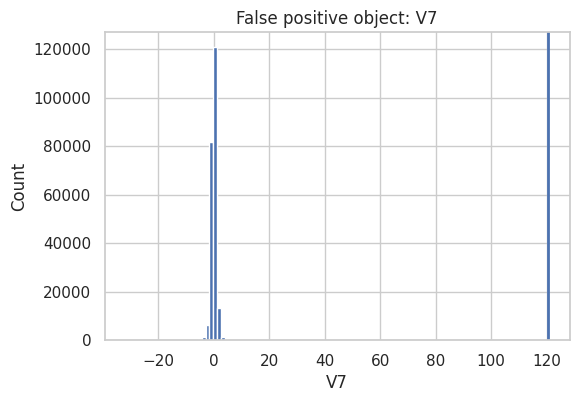

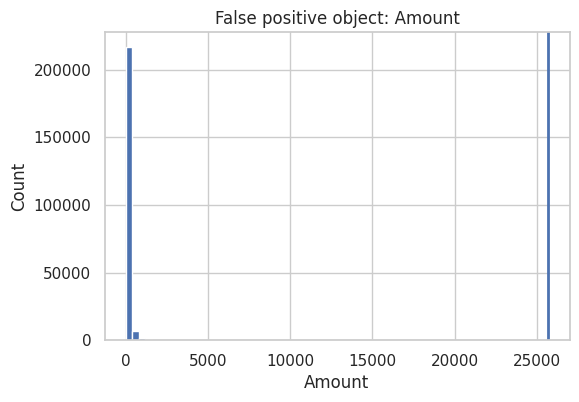

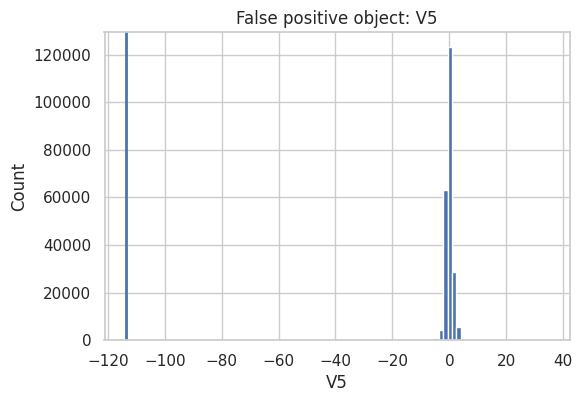

test index = 6513, anomaly_score = 0.7540


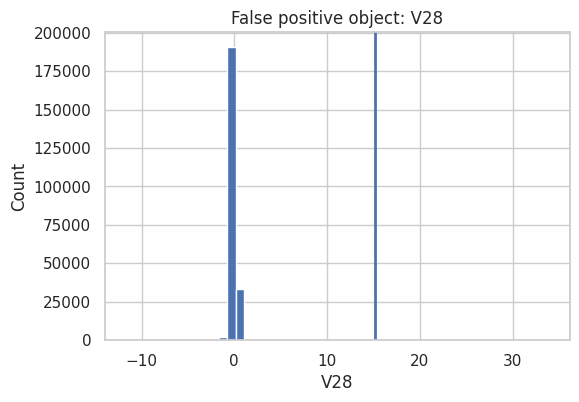

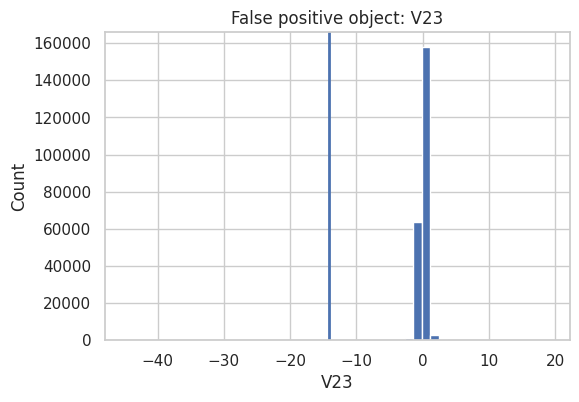

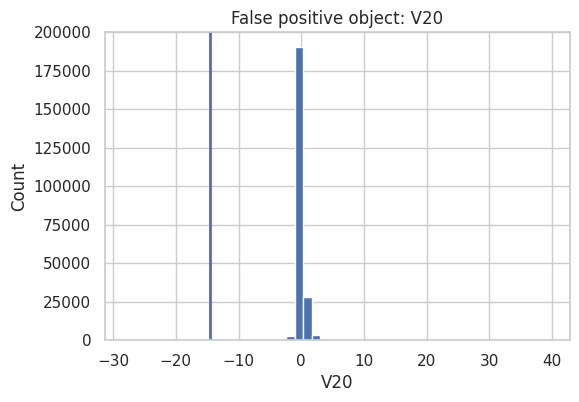

test index = 14411, anomaly_score = 0.7531


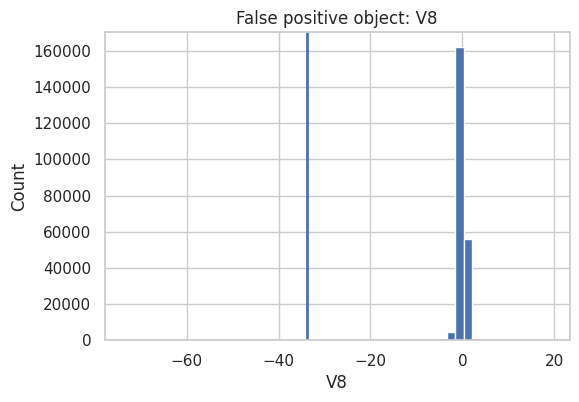

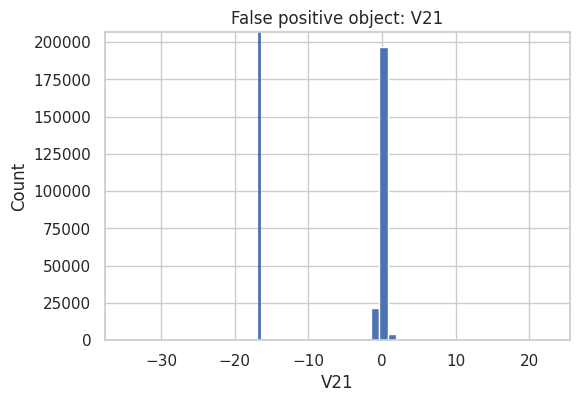

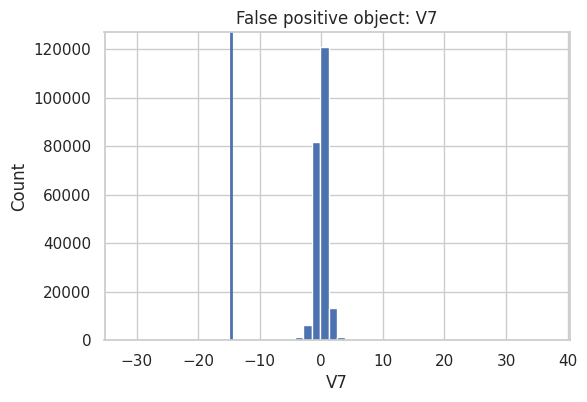

test index = 6517, anomaly_score = 0.7515


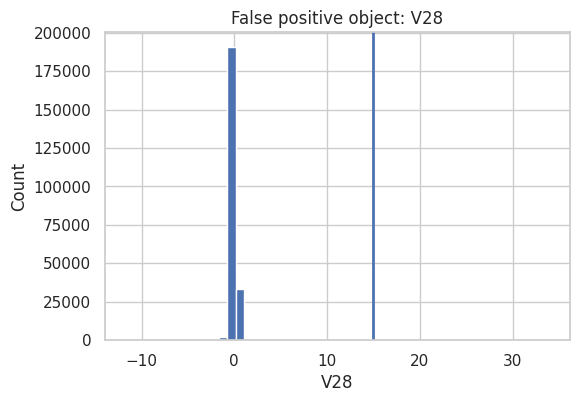

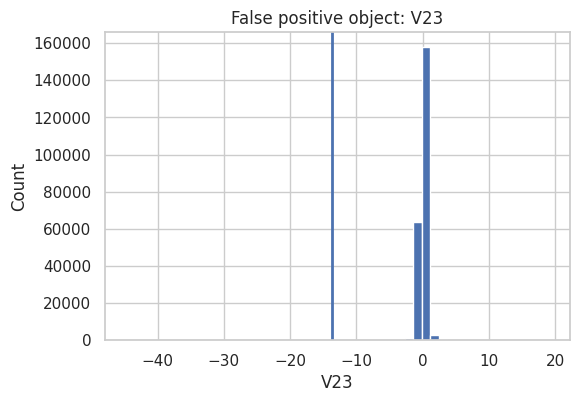

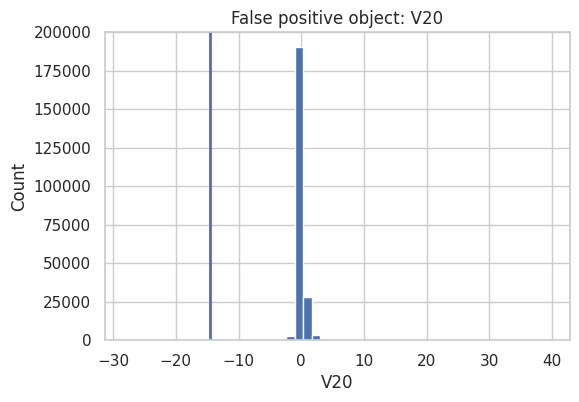

test index = 5517, anomaly_score = 0.7471


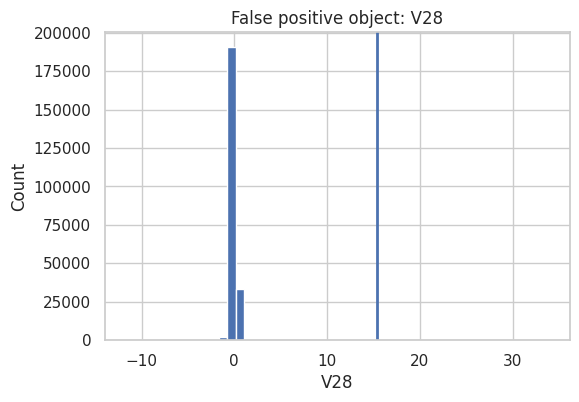

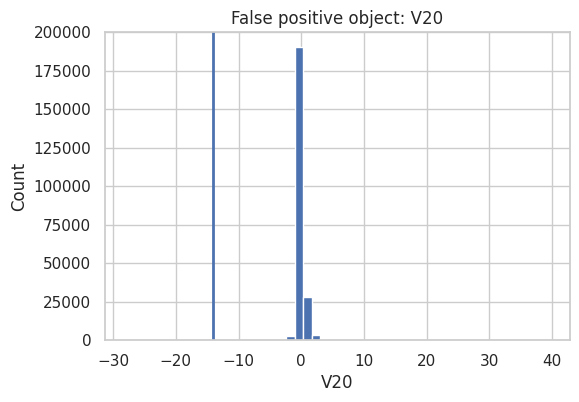

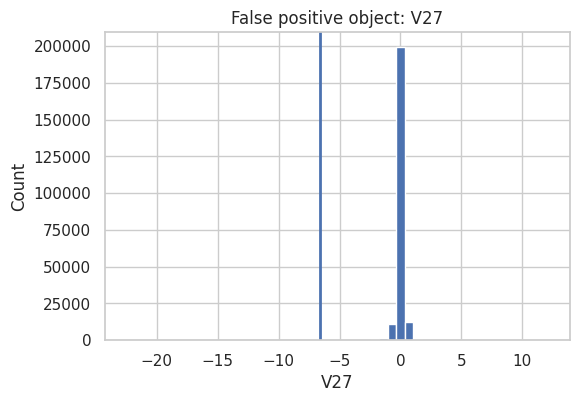

In [133]:
for idx in selected_fp_idx:
    row = test_analysis_df.loc[idx, feature_cols]
    z_scores = ((row - train_normal_df[feature_cols].mean()) / train_normal_df[feature_cols].std()).abs()
    top_features = z_scores.sort_values(ascending=False).head(3).index.tolist()

    print(f'test index = {idx}, anomaly_score = {test_analysis_df.loc[idx, "anomaly_score"]:.4f}')

    for feature in top_features:
        plt.figure(figsize=(6, 4))
        plt.hist(train_normal_df[feature], bins=50)
        plt.axvline(test_analysis_df.loc[idx, feature], linewidth=2)
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.title(f'False positive object: {feature}')
        plt.show()

Среди объектов с меткой 0 нашлись транзакции с высокой оценкой аномальности. EIF ищет просто редкие объекты, а не мошеннические операции напрямую, поэтому часть нормальных транзакций с редкими сочетаниями признаков или нетипичной суммой получает высокий anomaly score, хотя по разметке они относятся к обычному классу.